In [1]:
# ==============================
# STEP 1: Data Loaded Directly
# ==============================
# Running locally.

In [2]:
# ==============================
# STEP 2: Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

In [3]:
# ==============================
# STEP 3: Load Dataset
# ==============================
import os
DATASET_PATH = os.path.join("..", "Datasets", "IPF_Dataset.csv")
df = pd.read_csv(DATASET_PATH)

print("Shape:", df.shape)
df.head()

Shape: (5000, 8)


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,SYN000001,3,3009,86.574744,70,Male,Never smoked,Mild
1,SYN000002,56,1505,66.352414,63,Female,Never smoked,Moderate
2,SYN000003,20,1011,50.967610,78,Female,Never smoked,Severe
3,SYN000004,13,1878,44.744800,65,Male,Ex-smoker,Severe
4,SYN000005,19,3075,79.248053,73,Male,Never smoked,Mild


In [4]:
# ==============================
# STEP 4: Basic Dataset Check
# ==============================
print(df.info())
print("\nNull Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient        5000 non-null   object 
 1   Weeks          5000 non-null   int64  
 2   FVC            5000 non-null   int64  
 3   Percent        5000 non-null   float64
 4   Age            5000 non-null   int64  
 5   Sex            5000 non-null   object 
 6   SmokingStatus  5000 non-null   object 
 7   IPF_Severity   5000 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 312.6+ KB
None

Null Values:
Patient          0
Weeks            0
FVC              0
Percent          0
Age              0
Sex              0
SmokingStatus    0
IPF_Severity     0
dtype: int64

Columns:
Index(['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus',
       'IPF_Severity'],
      dtype='object')


In [5]:
# ==============================
# STEP 5: Drop Unnecessary Columns
# ==============================
# Patient is only an ID, not useful for training
if "Patient" in df.columns:
    df = df.drop(columns=["Patient"])

df.head()

,Weeks,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,3,3009,86.574744,70,Male,Never smoked,Mild
1,56,1505,66.352414,63,Female,Never smoked,Moderate
2,20,1011,50.967610,78,Female,Never smoked,Severe
3,13,1878,44.744800,65,Male,Ex-smoker,Severe
4,19,3075,79.248053,73,Male,Never smoked,Mild


In [6]:
# ==============================
# STEP 6: Encode Categorical Columns
# ==============================
label_encoders = {}

categorical_cols = ["Sex", "SmokingStatus", "IPF_Severity"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Encoding Done")
df.head()

Encoding Done


,Weeks,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,3,3009,86.574744,70,1,2,0
1,56,1505,66.352414,63,0,2,1
2,20,1011,50.967610,78,0,2,2
3,13,1878,44.744800,65,1,1,2
4,19,3075,79.248053,73,1,2,0


In [7]:
# ==============================
# STEP 7: Feature and Target Selection
# ==============================
X = df.drop(columns=["IPF_Severity"])
y = df["IPF_Severity"]

print("Features:", X.columns.tolist())
print("Target classes:", label_encoders["IPF_Severity"].classes_)

Features: ['Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']
Target classes: ['Mild' 'Moderate' 'Severe']


In [8]:
# ==============================
# STEP 8: Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4000, 6)
Testing Shape: (1000, 6)


In [9]:
# ==============================
# STEP 9: Feature Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# ==============================
# STEP 10: Train Multiple Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="mlogloss"
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Training Logistic Regression...
Accuracy: 0.908
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       440
           1       0.90      0.92      0.91       498
           2       0.87      0.63      0.73        62

    accuracy                           0.91      1000
   macro avg       0.90      0.83      0.86      1000
weighted avg       0.91      0.91      0.91      1000


Training Random Forest...


Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       440
           1       1.00      1.00      1.00       498
           2       1.00      1.00      1.00        62

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Training XGBoost...


Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       440
           1       0.99      1.00      1.00       498
           2       1.00      0.98      0.99        62

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [11]:
# ==============================
# STEP 11: Compare Model Accuracy
# ==============================
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
1,Random Forest,0.999
2,XGBoost,0.997
0,Logistic Regression,0.908


In [12]:
# ==============================
# STEP 12: Select Best Model
# ==============================
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Random Forest


           BEST MODEL : Random Forest

Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1 Score : 0.9990

Classification Report

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       440
    Moderate       1.00      1.00      1.00       498
      Severe       1.00      1.00      1.00        62

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



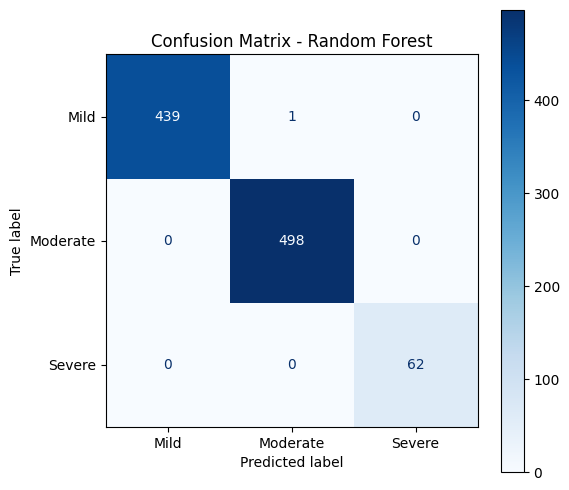

In [13]:
# ==============================
# STEP 13A: Evaluate Best Model
# ==============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict using the best model
if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# ------------------------------
# Performance Metrics
# ------------------------------
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print("="*60)
print(f"           BEST MODEL : {best_model_name}")
print("="*60)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ------------------------------
# Detailed Classification Report
# ------------------------------
print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoders["IPF_Severity"].classes_
))

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoders["IPF_Severity"].classes_
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()

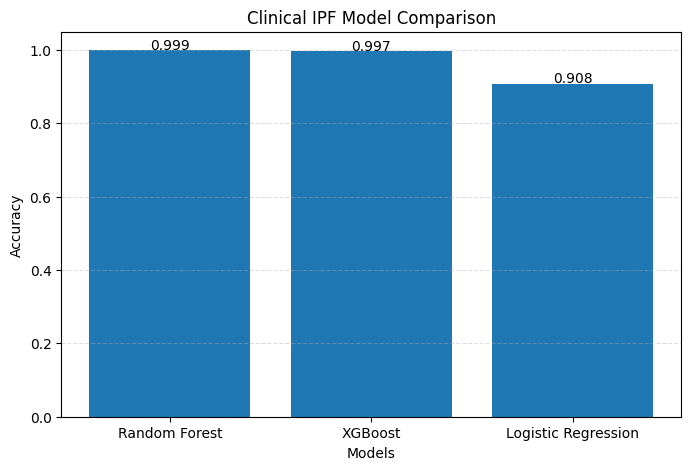

In [14]:
# ==============================
# STEP 13B: Compare All Models
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Clinical IPF Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.003, f"{v:.3f}", ha='center', fontsize=10)

plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [15]:
# ==============================
# STEP 14: Save Model, Scaler, Encoders
# ==============================
joblib.dump(best_model, "best_ipf_clinical_model.pkl")
joblib.dump(scaler, "ipf_scaler.pkl")
joblib.dump(label_encoders, "ipf_label_encoders.pkl")

print("Model files saved successfully.")

Model files saved successfully.


In [16]:
# ==============================
# STEP 15: Download Saved Files (Optional)
# ==============================
try:
    from google.colab import files
    files.download("best_ipf_clinical_model.pkl")
    files.download("ipf_scaler.pkl")
    files.download("ipf_label_encoders.pkl")
except ImportError:
    print("Saved files locally. (Google Colab files.download skipped)")

Saved files locally. (Google Colab files.download skipped)


In [17]:
# ==============================
# STEP 16: Test Prediction on One Sample
# ==============================

# Take one test sample
sample = X_test.iloc[[0]]

print("Sample Input:")
display(sample.T)   # vertical display to avoid column confusion

print("\nColumn Order:")
print(sample.columns.tolist())

# Prediction
if best_model_name == "Logistic Regression":
    sample_scaled = scaler.transform(sample)
    pred = best_model.predict(sample_scaled)
    prob = best_model.predict_proba(sample_scaled)
else:
    pred = best_model.predict(sample)
    prob = best_model.predict_proba(sample)

# Convert encoded prediction back to original label
predicted_class = label_encoders["IPF_Severity"].inverse_transform(pred)

print("\nPredicted IPF Severity:", predicted_class[0])

# Show probabilities
print("\nPrediction Probabilities:")
for cls, p in zip(label_encoders["IPF_Severity"].classes_, prob[0]):
    print(f"{cls}: {p*100:.2f}%")

Sample Input:


,2190
Weeks,44.000000
FVC,2972.000000
Percent,85.823191
Age,67.000000
Sex,1.000000
SmokingStatus,0.000000



Column Order:
['Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']

Predicted IPF Severity: Mild

Prediction Probabilities:
Mild: 98.50%
Moderate: 1.50%
Severe: 0.00%
